# Welltory COVID-19 and Wearables: Interactive Data Exploration

## Research Question

> **How are HRV measurements associated with participant characteristics, wearable activity, and time relative to reported COVID-19 symptom onset?**

## 1. Data Context and Sampling

Welltory conducted this remote observational study in 2020. Participants with a positive COVID-19 status recorded symptoms, heart rate variability (HRV), and wearable data.

The data is a voluntary convenience sample rather than a random sample. Results may be affected by selection bias, device differences, unequal measurements per person, and self-report error.

`hrv_measurements.csv` is the main table. It will be joined with participant information and daily wearable data. One row in the main table represents one HRV measurement.

**Data source:** [Welltory COVID-19 and Wearables GitHub repository](https://github.com/Welltory/hrv-covid19)  
**Retrieved:** September 15, 2026  
**Raw data:** Saved unchanged in `data/welltory_raw/`.

## 2. Setup and Load Data

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("data/welltory_raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/data"
FILES = ["participants.csv", "hrv_measurements.csv", "wearables.csv"]

In [2]:
# Download only files that are not already stored locally.
for filename in FILES:
    path = DATA_DIR / filename
    if not path.exists():
        urlretrieve(f"{BASE_URL}/{filename}", path)

In [3]:
participants = pd.read_csv(DATA_DIR / "participants.csv")
hrv = pd.read_csv(DATA_DIR / "hrv_measurements.csv")
wearables = pd.read_csv(DATA_DIR / "wearables.csv")

## 3. Data Structure

The three tables have different units of observation:

- `participants`: one row per participant
- `hrv`: one row per HRV measurement
- `wearables`: one row per participant per day

In [4]:
summary = pd.DataFrame({
    "rows": [len(participants), len(hrv), len(wearables)],
    "columns": [participants.shape[1], hrv.shape[1], wearables.shape[1]],
    "users": [participants.user_code.nunique(), hrv.user_code.nunique(), wearables.user_code.nunique()]
}, index=["participants", "hrv", "wearables"])
summary

,rows,columns,users
participants,185,8,185
hrv,3245,22,185
wearables,3098,18,79


In [5]:
display(participants.head())
display(hrv.head())
display(wearables.head())

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure
0,007b8190cf,2020-04-26,NaN,70.0,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2859.0,2859.0,NaN,NaN
1,01bad5a519,2020-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8574.0,NaN,57.90,NaN,NaN,2624.0,2624.0,NaN,NaN
2,01bad5a519,2020-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7462.0,NaN,59.10,NaN,NaN,2624.0,2624.0,NaN,NaN
3,01bad5a519,2020-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507.0,NaN,60.97,NaN,NaN,2624.0,2624.0,NaN,NaN
4,01bad5a519,2020-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10131.0,NaN,49.10,NaN,NaN,2624.0,2624.0,NaN,NaN


## 4. Key Features

The full field definitions are available in the repository's [data dictionary](https://github.com/Welltory/hrv-covid19/blob/master/datatypes.md).

| Group | Main features | Meaning |
|---|---|---|
| Participant | `gender`, `age_range`, `height`, `weight` | Participant characteristics |
| Date | `symptoms_onset` | Participant-reported date when COVID-19 symptoms began |
| Date | `measurement_datetime` | Date and time of an HRV measurement |
| Date | `day` | Date of a daily wearable summary |
| HRV | `sdnn` | Overall variation in normal heartbeat intervals, measured in milliseconds |
| HRV | `rmssd` | Short-term beat-to-beat variation, measured in milliseconds |
| HRV | `pnn50` | Percentage of successive heartbeat intervals that differ by more than 50 ms |
| Frequency | `lf` | Low-frequency HRV power; reflects a mixture of autonomic influences |
| Frequency | `hf` | High-frequency HRV power; strongly related to breathing and parasympathetic activity |
| Frequency | `vlf` | Very-low-frequency HRV power; its meaning is less clear in short measurements |
| Frequency | `lfhf` | Ratio of low- to high-frequency power; should not be treated as a simple stress score |
| Frequency | `total_power` | Total frequency-domain variation: LF + HF + VLF |
| Self-report | `how_feel`, `how_mood`, `how_sleep` | Post-measurement ratings |
| Activity | `resting_pulse`, `steps_count`, `distance` | Daily wearable measures |

## 5. Descriptive Statistics

In [6]:
hrv.describe().T

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.257935,12.201088,44.000,65.000,72.000,81.000,125.000
meanrr,3245.0,839.600366,137.420367,477.730,742.490,829.100,925.933,1346.740
mxdmn,3245.0,0.184635,0.107456,0.030,0.110,0.160,0.220,0.790
sdnn,3245.0,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631
rmssd,3245.0,52.814196,39.353213,6.340,28.985,42.869,62.485,310.800
pnn50,3245.0,20.615609,18.588156,0.000,6.060,16.160,29.290,91.920
mode,3245.0,0.837465,0.144769,0.475,0.725,0.825,0.925,1.325
amo,3245.0,46.788290,16.418873,12.000,35.000,45.000,57.000,98.000
lf,3245.0,927.038213,1455.424089,2.000,151.000,423.000,1059.000,15522.000
hf,3245.0,1125.041294,2490.540413,4.000,158.000,380.000,993.000,33490.000


## 6. Missing Values

In [7]:
tables = {"participants": participants, "hrv": hrv, "wearables": wearables}
missing = []

for name, df in tables.items():
    rates = df.isna().mean().mul(100)
    for column, rate in rates[rates > 0].items():
        missing.append([name, column, round(rate, 1)])

missing = pd.DataFrame(missing, columns=["table", "column", "missing_pct"])
missing.sort_values("missing_pct", ascending=False)

,table,column,missing_pct
10,wearables,average_spo2_value,98.7
11,wearables,body_temperature_avg,97.9
21,wearables,average_environment_exposure,95.2
20,wearables,average_headphone_exposure,92.6
12,wearables,stand_hours_total,82.9
17,wearables,active_calories_burned,61.3
16,wearables,total_number_of_flights_climbed,60.1
4,hrv,how_sleep,54.8
15,wearables,steps_speed,54.2
6,wearables,resting_pulse,51.1


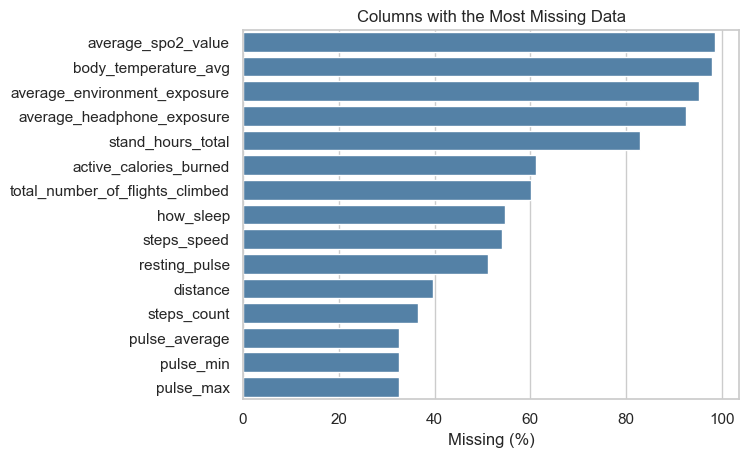

In [8]:
top_missing = missing.sort_values("missing_pct", ascending=False).head(15)
sns.barplot(data=top_missing, x="missing_pct", y="column", color="steelblue")
plt.title("Columns with the Most Missing Data")
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.show()

Wearable fields have the most missing data because devices collect different measurements. These columns should not be filled automatically. `how_sleep` and `tags` are also frequently missing in the HRV table.

## 7. Duplicates and Data Integrity

In [9]:
print("Duplicate participant IDs:", participants.user_code.duplicated().sum())
print("Duplicate HRV measurement IDs:", hrv.rr_code.duplicated().sum())
print("Duplicate wearable user-days:", wearables.duplicated(["user_code", "day"]).sum())
print("HRV users not in participants:", (~hrv.user_code.isin(participants.user_code)).sum())
print("Wearable users not in participants:", (~wearables.user_code.isin(participants.user_code)).sum())

Duplicate participant IDs: 0
Duplicate HRV measurement IDs: 0
Duplicate wearable user-days: 0
HRV users not in participants: 0
Wearable users not in participants: 0


No duplicate keys or unmatched users were found. The selected tables have good structural integrity.

## 8. Date Quality

In [10]:
participants["symptoms_onset"] = pd.to_datetime(participants["symptoms_onset"], errors="coerce")
hrv["measurement_datetime"] = pd.to_datetime(hrv["measurement_datetime"], errors="coerce")
wearables["day"] = pd.to_datetime(wearables["day"], errors="coerce")

print("Symptom dates:", participants.symptoms_onset.min(), "to", participants.symptoms_onset.max())
print("HRV dates:", hrv.measurement_datetime.min(), "to", hrv.measurement_datetime.max())
print("Wearable dates:", wearables.day.min(), "to", wearables.day.max())

Symptom dates: 1967-01-30 00:00:00 to 2022-04-21 00:00:00
HRV dates: 2019-12-31 06:08:29 to 2020-06-19 11:40:13
Wearable dates: 2020-01-01 00:00:00 to 2020-06-19 00:00:00


The symptom dates range from 1967 to 2022, while the study data was collected around 2020. These dates require further investigation. A valid date format does not guarantee an accurate value.

## 9. Distributions and Outliers

In [11]:
hrv_columns = ["bpm", "sdnn", "rmssd", "pnn50", "lf", "hf", "vlf", "lfhf", "total_power"]
hrv[hrv_columns].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.26,12.20,44.00,65.00,72.00,81.00,125.00
sdnn,3245.0,52.49,29.37,9.52,32.58,46.92,64.41,206.63
rmssd,3245.0,52.81,39.35,6.34,28.98,42.87,62.48,310.80
pnn50,3245.0,20.62,18.59,0.00,6.06,16.16,29.29,91.92
lf,3245.0,927.04,1455.42,2.00,151.00,423.00,1059.00,15522.00
hf,3245.0,1125.04,2490.54,4.00,158.00,380.00,993.00,33490.00
vlf,3245.0,578.23,876.68,1.00,116.00,293.00,693.00,18468.00
lfhf,3245.0,2.40,5.75,0.03,0.40,0.86,1.97,105.62
total_power,3245.0,2630.31,3912.25,44.00,620.00,1387.00,2906.00,41118.00


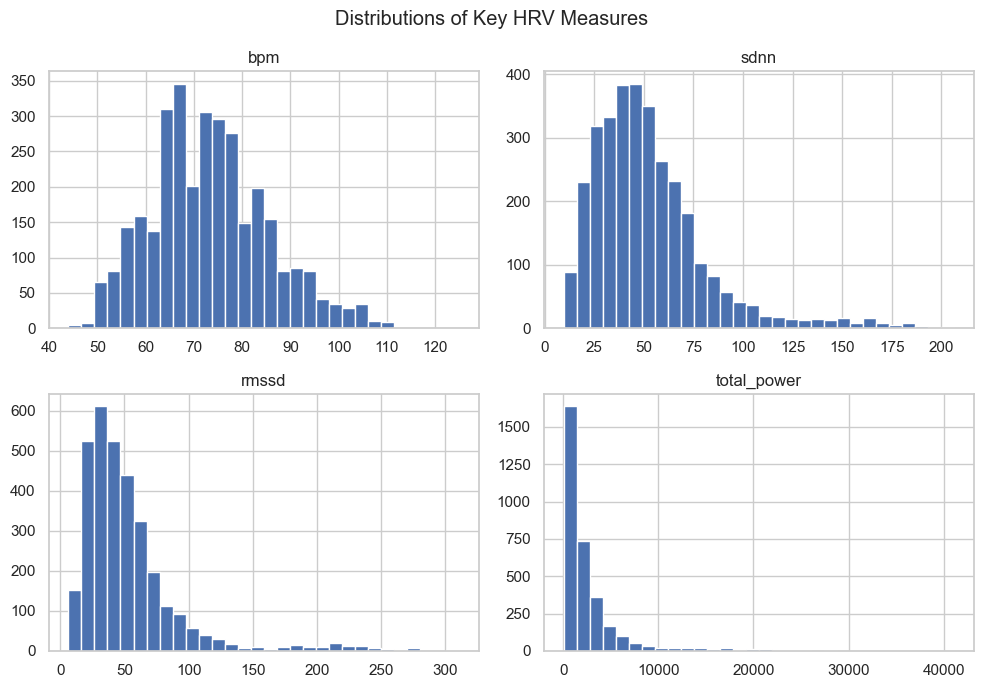

In [12]:
hrv[["bpm", "sdnn", "rmssd", "total_power"]].hist(figsize=(10, 7), bins=30)
plt.suptitle("Distributions of Key HRV Measures")
plt.tight_layout()
plt.show()

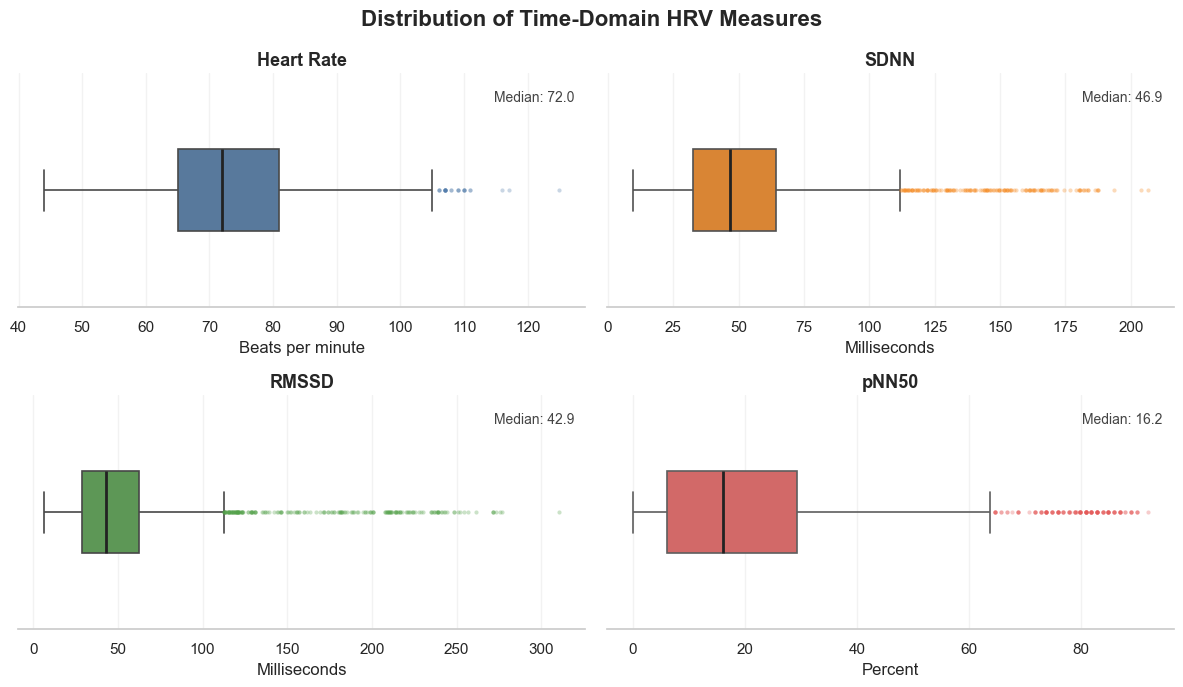

In [19]:
variables = {
    "bpm": ("Heart Rate", "Beats per minute", "#4C78A8"),
    "sdnn": ("SDNN", "Milliseconds", "#F58518"),
    "rmssd": ("RMSSD", "Milliseconds", "#54A24B"),
    "pnn50": ("pNN50", "Percent", "#E45756")
}

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, (column, (title, unit, color)) in zip(axes, variables.items()):
    median = hrv[column].median()

    sns.boxplot(
        x=hrv[column],
        ax=ax,
        color=color,
        width=0.35,
        linewidth=1.2,
        flierprops={
            "marker": "o",
            "markersize": 3,
            "markerfacecolor": color,
            "markeredgecolor": "none",
            "alpha": 0.3
        },
        medianprops={
            "color": "#222222",
            "linewidth": 2
        }
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(unit)
    ax.set_ylabel("")
    ax.text(
        0.98, 0.88,
        f"Median: {median:.1f}",
        transform=ax.transAxes,
        ha="right",
        fontsize=10,
        color="#444444"
    )

    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    sns.despine(ax=ax, left=True)

fig.suptitle(
    "Distribution of Time-Domain HRV Measures",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The boxplots focus on heart rate and time-domain HRV measures because they are central to the research question and have comparable ranges. Frequency-domain variables are examined separately because they are more strongly skewed and have much larger scales.

Heart rate (bpm) is relatively symmetric and has few outliers. The time-domain HRV measures (sdnn, rmssd, and pnn50) are right-skewed and contain many high-value observations. These observations are not automatically errors because unusually high HRV values may be valid. Median and IQR are therefore more appropriate than mean and standard deviation for describing these distributions.

In [14]:
outliers = {}

for column in hrv_columns:
    q1 = hrv[column].quantile(0.25)
    q3 = hrv[column].quantile(0.75)
    iqr = q3 - q1
    outside = (hrv[column] < q1 - 1.5 * iqr) | (hrv[column] > q3 + 1.5 * iqr)
    outliers[column] = outside.sum()

pd.Series(outliers, name="outlier_count").sort_values(ascending=False)

lfhf           382
hf             334
lf             291
total_power    266
vlf            262
rmssd          195
sdnn           149
pnn50          127
bpm             25
Name: outlier_count, dtype: int64

The IQR check also identifies many potential outliers in the frequency-domain variables. These variables will be examined separately before any values are removed or transformed.

## 10. Measurements per Participant

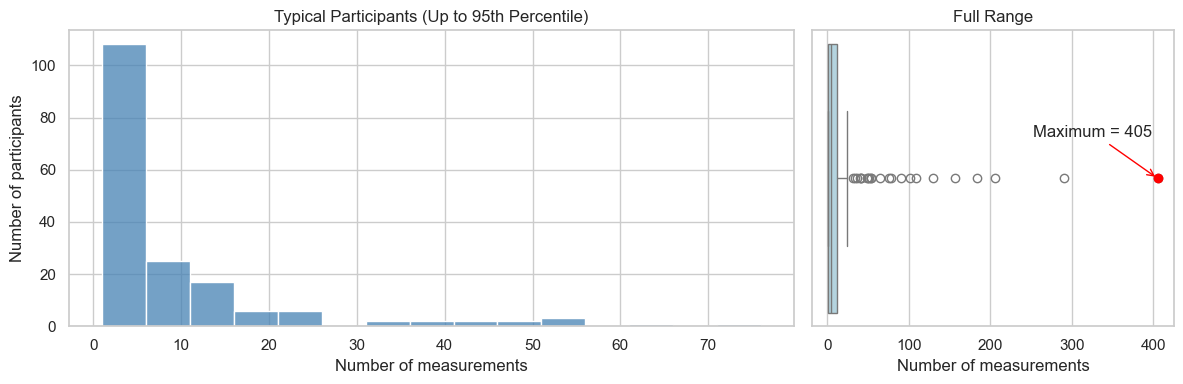

In [17]:
measurements_per_user = hrv.groupby("user_code").size()

cutoff = measurements_per_user.quantile(0.95)
max_value = measurements_per_user.max()

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [2, 1]}
)

# Typical participants
sns.histplot(
    measurements_per_user[measurements_per_user <= cutoff],
    binwidth=5,
    color="steelblue",
    edgecolor="white",
    ax=axes[0]
)
axes[0].set_title("Typical Participants (Up to 95th Percentile)")
axes[0].set_xlabel("Number of measurements")
axes[0].set_ylabel("Number of participants")

# Full range, including extreme values
sns.boxplot(
    x=measurements_per_user,
    color="lightblue",
    ax=axes[1]
)
axes[1].scatter(max_value, 0, color="red", zorder=3)
axes[1].annotate(
    f"Maximum = {max_value}",
    xy=(max_value, 0),
    xytext=(-90, 30),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "red"}
)
axes[1].set_title("Full Range")
axes[1].set_xlabel("Number of measurements")

plt.tight_layout()
plt.show()

The median participant has 4 HRV measurements, but one participant has 405. Participants with many measurements could have too much influence on measurement-level results. Later comparisons should also use participant-level summaries.

## 11. Data Cleaning

### Remove Duplicates

Duplicate keys are removed even though none were found in the current data.

In [20]:
participants_clean = participants.drop_duplicates("user_code").copy()
hrv_clean = hrv.drop_duplicates("rr_code").copy()
wearables_clean = wearables.drop_duplicates(["user_code", "day"]).copy()

### Handle Invalid Dates

The study was conducted in 2020, so symptom dates from other years are treated as invalid and changed to missing values.

In [21]:
invalid_dates = (
    participants_clean["symptoms_onset"].notna()
    & (participants_clean["symptoms_onset"].dt.year != 2020)
)

print("Invalid symptom dates:", invalid_dates.sum())
participants_clean.loc[invalid_dates, "symptoms_onset"] = pd.NaT

Invalid symptom dates: 13


### Handle Missing Values

Wearable columns with more than 80% missing values are removed. Other missing values are kept because automatic imputation could create false health measurements.

In [22]:
high_missing_columns = wearables_clean.columns[wearables_clean.isna().mean() > 0.80]
wearables_clean = wearables_clean.drop(columns=high_missing_columns)
print("Removed columns:", list(high_missing_columns))

Removed columns: ['average_spo2_value', 'body_temperature_avg', 'stand_hours_total', 'average_headphone_exposure', 'average_environment_exposure']


### Handle Outliers and Skewness

IQR outliers are kept because they may be valid physiological measurements. Right-skewed variables are log-transformed to reduce the influence of extreme values.

In [23]:
skewed_columns = ["sdnn", "rmssd", "pnn50", "lf", "hf", "vlf", "lfhf", "total_power"]

for column in skewed_columns:
    hrv_clean[f"log_{column}"] = np.log1p(hrv_clean[column])

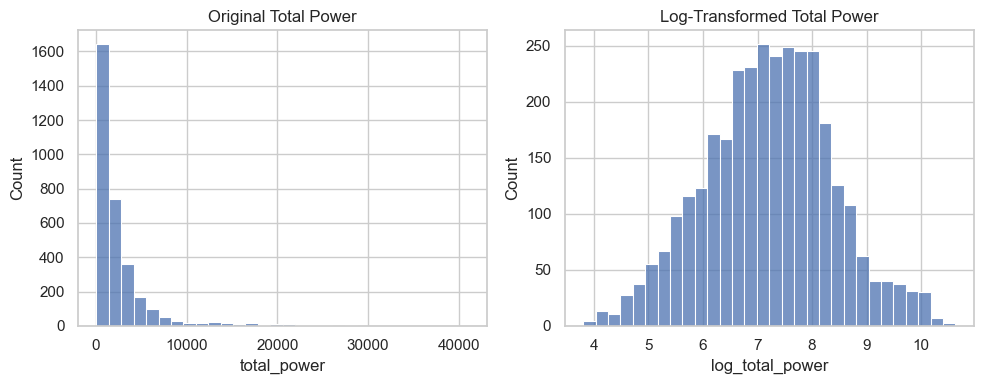

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(hrv_clean["total_power"], bins=30, ax=axes[0])
sns.histplot(hrv_clean["log_total_power"], bins=30, ax=axes[1])
axes[0].set_title("Original Total Power")
axes[1].set_title("Log-Transformed Total Power")
plt.tight_layout()
plt.show()

The log transformation reduces right skewness without deleting high values. Original columns are retained for interpretation.

## 12. Merge Tables and Create a New Feature

`days_from_onset` measures the number of days between symptom onset and each HRV measurement. Negative values are before symptom onset; positive values are after onset.

In [25]:
hrv_clean["measurement_date"] = hrv_clean["measurement_datetime"].dt.normalize()

analysis = hrv_clean.merge(participants_clean, on="user_code", how="left")
analysis = analysis.merge(
    wearables_clean,
    left_on=["user_code", "measurement_date"],
    right_on=["user_code", "day"],
    how="left"
)

analysis["days_from_onset"] = (
    analysis["measurement_date"] - analysis["symptoms_onset"]
).dt.days

analysis[["user_code", "measurement_date", "symptoms_onset", "days_from_onset"]].head()

,user_code,measurement_date,symptoms_onset,days_from_onset
0,007b8190cf,2020-04-21,NaT,NaN
1,007b8190cf,2020-04-26,NaT,NaN
2,013f6d3e5b,2020-05-15,2020-05-15,0.0
3,013f6d3e5b,2020-05-19,2020-05-15,4.0
4,01bad5a519,2019-12-31,2020-04-05,-96.0


In [26]:
print("Analysis rows:", len(analysis))
print("Rows with symptom timing:", analysis["days_from_onset"].notna().sum())
print("Rows matched with wearable data:", analysis["day"].notna().sum())

Analysis rows: 3245
Rows with symptom timing: 2685
Rows matched with wearable data: 1976


The left joins preserve all HRV measurements. Missing symptom dates or wearable records remain missing rather than being estimated.

## 13. Variable Relationships

### Relationships Between HRV Measures

Participant-level medians are used so that frequent users do not dominate the results. Spearman correlation is used because the HRV variables are skewed.

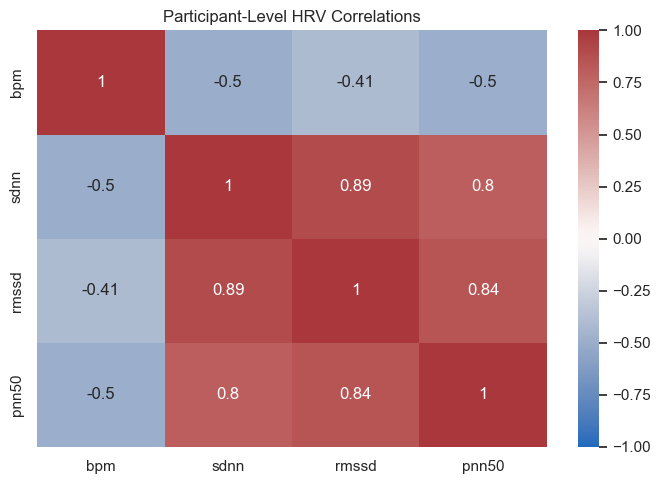

In [28]:
participant_hrv = analysis.groupby(
    ["user_code", "gender", "age_range"], as_index=False
)[["bpm", "sdnn", "rmssd", "pnn50"]].median()

hrv_correlation = participant_hrv[["bpm", "sdnn", "rmssd", "pnn50"]].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(hrv_correlation, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Participant-Level HRV Correlations")
plt.tight_layout()
plt.show()

`sdnn`, `rmssd`, and `pnn50` are strongly positively related. Heart rate has a moderate negative relationship with these HRV measures. Correlation does not show causation.

### Participant Characteristics

/var/folders/67/6l6j58b51m384qc5f923mkcm0000gn/T/ipykernel_31110/3331058630.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([
/var/folders/67/6l6j58b51m384qc5f923mkcm0000gn/T/ipykernel_31110/3331058630.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([


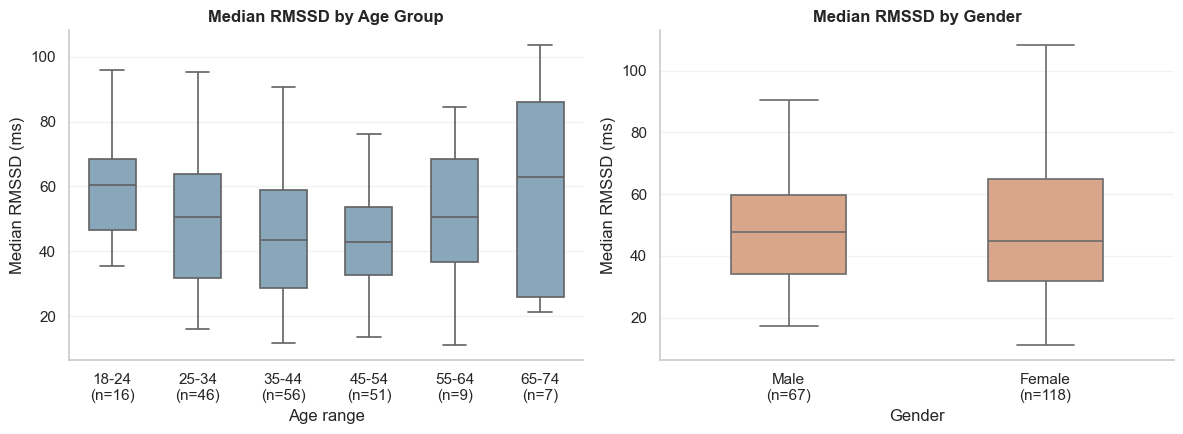

In [31]:
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74"]

age_counts = participant_hrv["age_range"].value_counts()
gender_counts = participant_hrv["gender"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# RMSSD by age
sns.boxplot(
    data=participant_hrv,
    x="age_range",
    y="rmssd",
    order=age_order,
    color="#7FA9C4",
    width=0.55,
    showfliers=False,
    linewidth=1.2,
    ax=axes[0]
)

axes[0].set_title("Median RMSSD by Age Group", fontweight="bold")
axes[0].set_xlabel("Age range")
axes[0].set_ylabel("Median RMSSD (ms)")
axes[0].set_xticklabels([
    f"{age}\n(n={age_counts.get(age, 0)})"
    for age in age_order
])

# RMSSD by gender
sns.boxplot(
    data=participant_hrv,
    x="gender",
    y="rmssd",
    order=["m", "f"],
    color="#E5A47E",
    width=0.45,
    showfliers=False,
    linewidth=1.2,
    ax=axes[1]
)

axes[1].set_title("Median RMSSD by Gender", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Median RMSSD (ms)")
axes[1].set_xticklabels([
    f"Male\n(n={gender_counts.get('m', 0)})",
    f"Female\n(n={gender_counts.get('f', 0)})"
])

for ax in axes:
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

RMSSD differs across groups, but the pattern is not clearly monotonic by age. The two oldest groups have very small samples, so their results are uncertain. Gender differences are modest relative to the variation within each group.

### Symptom Timing

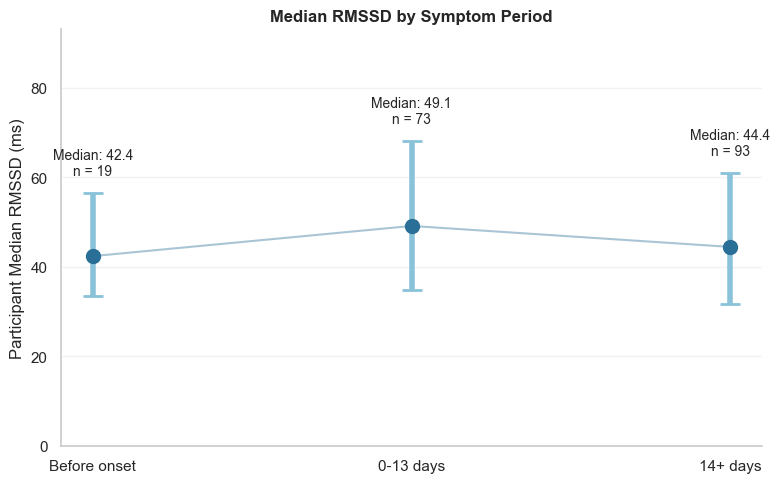

In [34]:
period_order = ["Before onset", "0-13 days", "14+ days"]

period_data = analysis.dropna(subset=["days_from_onset"]).copy()
period_data["symptom_period"] = pd.cut(
    period_data["days_from_onset"],
    bins=[-np.inf, -1, 13, np.inf],
    labels=period_order
)

period_hrv = (
    period_data
    .groupby(["user_code", "symptom_period"], observed=True)["rmssd"]
    .median()
    .reset_index(name="median_rmssd")
)

period_summary = (
    period_hrv.groupby("symptom_period", observed=True)["median_rmssd"]
    .agg(
        count="count",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(period_order)
)

x = np.arange(len(period_summary))

lower_error = period_summary["median"] - period_summary["q1"]
upper_error = period_summary["q3"] - period_summary["median"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    x,
    period_summary["median"],
    yerr=[lower_error, upper_error],
    fmt="o",
    markersize=10,
    color="#2A6F97",
    ecolor="#89C2D9",
    elinewidth=4,
    capsize=7,
    capthick=2
)

ax.plot(
    x,
    period_summary["median"],
    color="#2A6F97",
    linewidth=1.5,
    alpha=0.4
)

for i, row in enumerate(period_summary.itertuples()):
    ax.text(
        i,
        row.q3 + 4,
        f"Median: {row.median:.1f}\nn = {row.count}",
        ha="center",
        fontsize=10
    )

ax.set_xticks(x)
ax.set_xticklabels(period_order)
ax.set_title("Median RMSSD by Symptom Period", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Participant Median RMSSD (ms)")
ax.set_ylim(0, period_summary["q3"].max() + 25)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

In [33]:
period_hrv.groupby("symptom_period", observed=True)["median_rmssd"].agg(["count", "median"]).round(1)

,count,median
symptom_period,,
Before onset,19,42.4
0-13 days,73,49.1
14+ days,93,44.4


Median RMSSD is slightly higher during days 0-13 than before onset or after day 14. The groups contain different participants and measurement counts, so this is descriptive evidence rather than a causal or clinical conclusion.

### Wearable Activity

In [27]:
daily_data = analysis.dropna(subset=["steps_count"]).groupby(
    ["user_code", "measurement_date"], as_index=False
).agg(
    rmssd=("rmssd", "median"),
    sdnn=("sdnn", "median"),
    steps_count=("steps_count", "first"),
    resting_pulse=("resting_pulse", "first")
)

daily_data[["steps_count", "resting_pulse", "rmssd", "sdnn"]].corr(method="spearman").round(2)

,steps_count,resting_pulse,rmssd,sdnn
steps_count,1.00,-0.20,0.01,0.06
resting_pulse,-0.20,1.00,-0.19,-0.32
rmssd,0.01,-0.19,1.00,0.88
sdnn,0.06,-0.32,0.88,1.00


Same-day step count has almost no relationship with RMSSD or SDNN in the available data. Resting pulse has a weak negative relationship with both HRV measures. Wearable results are limited because only a subset of participants has matching data.

## 14. Data Quality Assessment

| Dimension | Assessment |
|---|---|
| Data profiling | Table sizes, data types, summary statistics, missing values, duplicates, ranges, and relationships were examined. |
| Completeness | Core HRV fields are complete, but optional survey and wearable fields contain substantial missing data. Only 1,976 HRV records matched same-day wearable data. |
| Accuracy | Thirteen symptom dates outside 2020 were treated as invalid. Device measurements and self-reported information could not be independently verified. |
| Consistency | Date fields were converted to a common format. Category labels and measurement units were consistent with the data dictionary. |
| Integrity | No duplicate keys or unmatched user IDs were found. Left joins preserved all 3,245 HRV records. |
| Lineage and provenance | Data came from Welltory's public GitHub repository. Raw files were stored unchanged, and all cleaning steps were documented in this notebook. |

## 15. Main Findings

- `sdnn`, `rmssd`, and `pnn50` are strongly positively related.
- Heart rate has a moderate negative relationship with the HRV measures.
- RMSSD varies across age and gender groups, but no clear age pattern is present.
- Median RMSSD is slightly higher during days 0-13 after symptom onset.
- Same-day step count has almost no relationship with RMSSD or SDNN.
- Resting pulse has a weak negative relationship with both HRV measures.

## 16. Limitations

- The participants form a voluntary convenience sample, not a random population sample.
- Wearable data is available for only part of the sample.
- Participants contributed very different numbers of HRV measurements.
- Devices, measurement conditions, and self-reported information may differ across participants.
- The analysis is observational and does not establish causation or clinical effects.

## 17. Conclusion

The dataset is useful for exploring HRV patterns around COVID-19 symptoms, but missing wearable data, uneven measurement frequency, and self-selection limit generalization. Time-domain HRV measures are closely related, while activity and demographic relationships are weak or uncertain. The results should be treated as descriptive associations rather than causal or clinical evidence.